# Week 1 -- Data Acquisition + Exploratory Data Analysis

Loads all 5 ADMET datasets used throughout this project via PyTDC, then, for each one in turn: counts/missing-data checks, class balance or target distribution, duplicate-SMILES and label-conflict/cross-split-leakage checks, and molecular-descriptor-vs-target plots (RDKit). Each dataset's own section ends with a **Decisions** cell recording what was found and what (if anything) was deferred to modeling time -- those decisions get picked back up in `Featurization_Baseline.ipynb` (Week 2) and `Model_Improvement.ipynb` (Week 3). See `NOTES.md` for the plain-language "why this property matters" writeups and technical-concept definitions referenced throughout.

In [1]:
from tdc.single_pred import ADME
from tdc.single_pred import Tox

# Solubility AqSolDB dataset
# predicts the solubility of a compound in water
solubility = ADME(name = 'Solubility_AqSolDB')
solubility_split = solubility.get_split()

# BBB permeability dataset
# predicts whether a compound can cross the blood-brain barrier (BBB)
BBB = ADME(name = 'BBB_Martins')
BBB_split = BBB.get_split()

# hERG blockade dataset
# predicts cardiotoxicity risk
hERG = Tox(name = 'hERG')
hERG_split = hERG.get_split()

# CYP3A4 inhibition dataset
# predicts drug-drug interaction risk via metabolism by CYP3A4 enzyme
CYP3A4 = ADME(name = 'CYP3A4_Veith')
CYP3A4_split = CYP3A4.get_split()

# Clearance Hepatocyte AZ dataset
# how fast the body eliminates the compound via liver metabolism
clearance = ADME(name = 'Clearance_Hepatocyte_AZ')
clearance_split = clearance.get_split()



Found local copy...


Loading...


Done!


Found local copy...


Loading...


...

Loading...


Done!


Found local copy...


Loading...


Done!


## 1. Solubility (AqSolDB) — EDA

Predicts aqueous solubility (log solubility, mol/L) of a compound — a regression task. Affects formulation and bioavailability. See `NOTES.md` for why this property matters in drug development.

In [2]:
solubility_split['train'].head()

,Drug_ID,Drug,Y
0,Benzo[cd]indol-2(1H)-one,O=C1Nc2cccc3cccc1c23,-3.254767
1,4-chlorobenzaldehyde,O=Cc1ccc(Cl)cc1,-2.177078
2,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,c1cc(N(CC2CO2)CC2CO2)ccc1Cc1ccc(N(CC2CO2)CC2CO...,-4.662065
3,vinyltoluene,C=Cc1cccc(C)c1,-3.123150
4,3-(3-ethylcyclopentyl)propanoic acid,CCC1CCC(CCC(=O)O)C1,-3.286116


In [3]:
# How many compounds?
for name, df in solubility_split.items():
    print(f"{name}: {df.shape[0]} compounds, {df.shape[1]} columns")

total = sum(df.shape[0] for df in solubility_split.values())
print(f"\ntotal: {total} compounds")

train: 6988 compounds, 3 columns
valid: 998 compounds, 3 columns
test: 1996 compounds, 3 columns

total: 9982 compounds


In [4]:
# Any missing data?
for name, df in solubility_split.items():
    print(f"--- {name} ---")
    print(df.isna().sum())
    print()

--- train ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- valid ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- test ---
Drug_ID    0
Drug       0
Y          0
dtype: int64



**Class balance:** not applicable — this is a regression task (`Y` is a continuous log-solubility value, not a class label). Instead we look at the distribution of `Y`.

count    6988.000000
mean       -2.862946
std         2.387322
min       -13.171900
25%        -4.280085
50%        -2.591850
75%        -1.155815
max         2.137682
Name: Y, dtype: float64


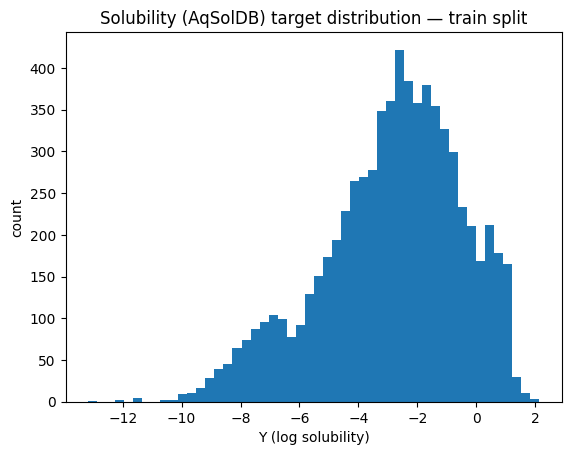

In [5]:
import matplotlib.pyplot as plt

print(solubility_split['train']['Y'].describe())

plt.hist(solubility_split['train']['Y'], bins=50)
plt.xlabel('Y (log solubility)')
plt.ylabel('count')
plt.title('Solubility (AqSolDB) target distribution — train split')
plt.show()

In [6]:
# Sanity check: any duplicate compounds?
train = solubility_split['train']
print("duplicate Drug_ID:", train['Drug_ID'].duplicated().sum())
print("duplicate SMILES (Drug):", train['Drug'].duplicated().sum())

duplicate Drug_ID: 37
duplicate SMILES (Drug): 0


### Descriptor plots

Five basic molecular descriptors, computed with RDKit, checked against the target for intuition:
- **MolWt** — molecular weight (size)
- **MolLogP** — Crippen LogP, a computed estimate of lipophilicity (octanol/water partition)
- **TPSA** — topological polar surface area, a proxy for how easily a molecule crosses membranes
- **NumHDonors** / **NumHAcceptors** — hydrogen-bond donor/acceptor counts

These five are the core inputs to Lipinski's Rule of Five and show up throughout ADMET reasoning — they'll be relevant in every dataset section below, not just this one.

**Salt stripping:** some SMILES in these datasets represent salts written as multiple disconnected fragments (e.g. a drug cation plus a counter-ion, joined by `.`). Computing descriptors on the full multi-fragment SMILES inflates values like MolWt/MolLogP (see `CLAUDE.md`'s "Outliers to investigate" — e.g. hERG's Clofilium phosphate came out ~3x too heavy this way). `compute_descriptors` below keeps only the largest fragment (by heavy-atom count) per molecule before computing descriptors — the standard cheminformatics fix, since the largest fragment is almost always the actual drug, not a counter-ion.

In [7]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

train = solubility_split['train']

def largest_fragment(mol):
    frags = Chem.GetMolFrags(mol, asMols=True)
    if len(frags) == 1:
        return mol
    return max(frags, key=lambda m: m.GetNumHeavyAtoms())

def compute_descriptors(smiles_series):
    rows = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        mol = largest_fragment(mol)
        rows.append({
            'MolWt': Descriptors.MolWt(mol),
            'MolLogP': Descriptors.MolLogP(mol),
            'TPSA': Descriptors.TPSA(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        })
    return pd.DataFrame(rows)

desc = compute_descriptors(train['Drug'])
desc['Y'] = train['Y'].values
desc.describe()

[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors


[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:38] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not r

[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors


[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors
[10:45:39] WARNING: not removing hydrogen atom without neighbors


,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,Y
count,6988.000000,6988.000000,6988.000000,6988.000000,6988.000000,6988.000000
mean,248.523692,2.230707,58.295212,1.052089,3.313537,-2.862946
std,148.963210,2.562167,54.090687,1.372877,3.104682,2.387322
min,6.941000,-15.230600,0.000000,0.000000,0.000000,-13.171900
25%,152.928000,0.754975,26.020000,0.000000,1.000000,-4.280085
50%,221.256000,2.022630,49.080000,1.000000,3.000000,-2.591850
75%,307.563250,3.444800,77.350000,2.000000,4.000000,-1.155815
max,2285.676000,28.825200,742.740000,21.000000,40.000000,2.137682


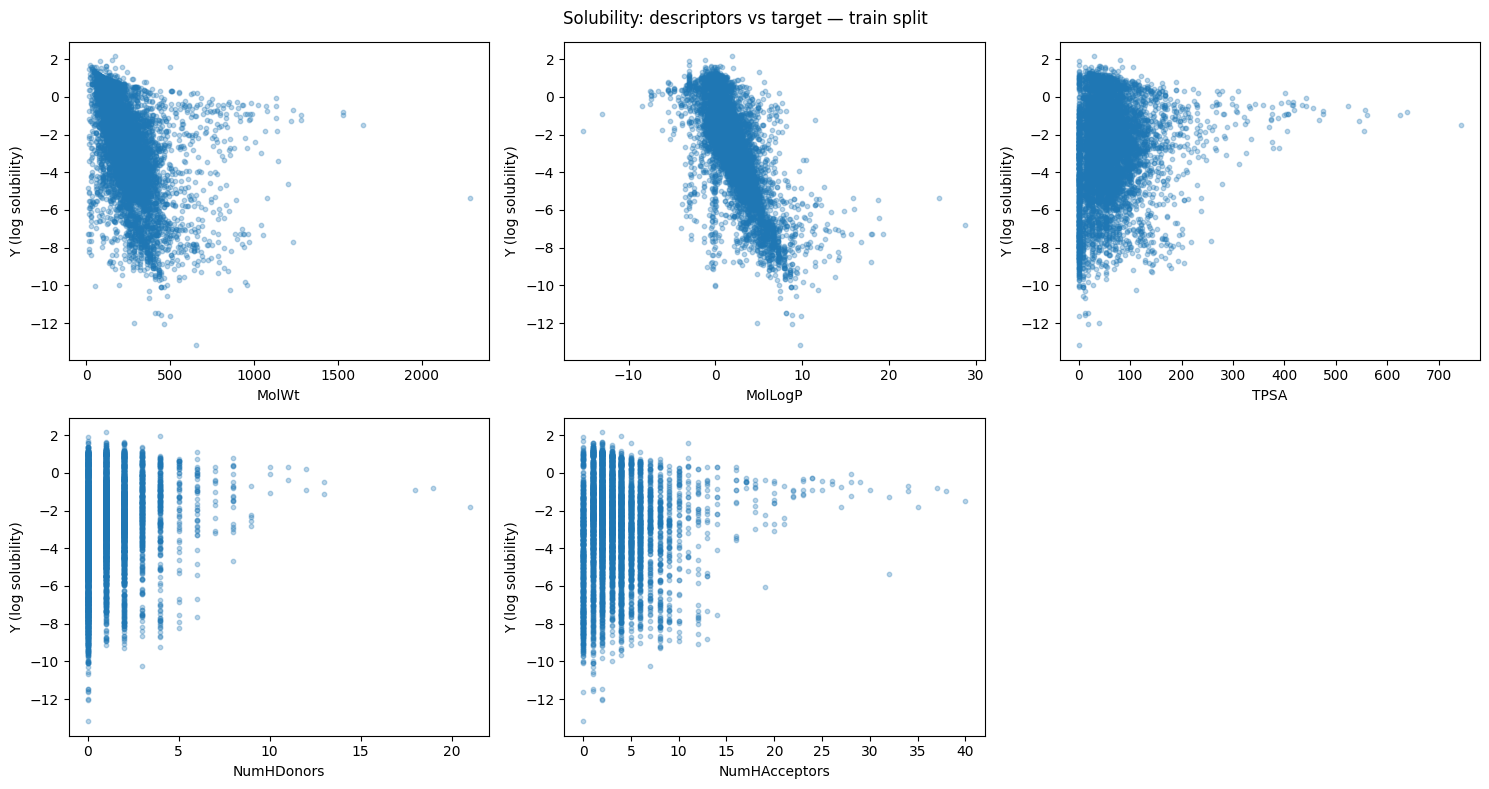

In [8]:
descriptor_cols = ['MolWt', 'MolLogP', 'TPSA', 'NumHDonors', 'NumHAcceptors']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, descriptor_cols):
    ax.scatter(desc[col], desc['Y'], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Y (log solubility)')

axes[-1].axis('off')  # unused 6th subplot
fig.suptitle('Solubility: descriptors vs target — train split')
plt.tight_layout()
plt.show()

## 2. BBB Permeability (BBB_Martins) — EDA

Predicts whether a compound can cross the blood-brain barrier — a binary classification task (`Y` = 1 permeable, 0 not permeable). Critical for CNS drug development. See `NOTES.md` for why this property matters in drug development.

In [9]:
BBB_split['train'].head()

,Drug_ID,Drug,Y
0,Terbutylchlorambucil,CC(C)(C)OC(=O)CCCc1ccc(N(CCCl)CCCl)cc1,1
1,40730,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,1
2,cloxacillin,Cc1onc(-c2ccccc2Cl)c1C(=O)N[C@@H]1C(=O)N2[C@@H...,1
3,cefoperazone,CCN1CCN(C(=O)N[C@@H](C(=O)N[C@@H]2C(=O)N3C(C(=...,1
4,rolitetracycline,CN(C)[C@@H]1C(=O)/C(=C(/O)NCN2CCCC2)C(=O)[C@@]...,1


In [10]:
# How many compounds?
for name, df in BBB_split.items():
    print(f"{name}: {df.shape[0]} compounds, {df.shape[1]} columns")

total = sum(df.shape[0] for df in BBB_split.values())
print(f"\ntotal: {total} compounds")

train: 1421 compounds, 3 columns
valid: 203 compounds, 3 columns
test: 406 compounds, 3 columns

total: 2030 compounds


In [11]:
# Any missing data?
for name, df in BBB_split.items():
    print(f"--- {name} ---")
    print(df.isna().sum())
    print()

--- train ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- valid ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- test ---
Drug_ID    0
Drug       0
Y          0
dtype: int64



Y
1    1096
0     325
Name: count, dtype: int64

Y
1    0.771288
0    0.228712
Name: proportion, dtype: float64


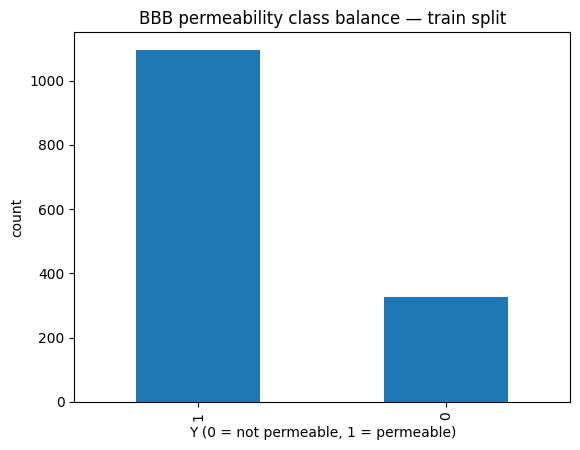

In [12]:
# Class balance
train = BBB_split['train']
print(train['Y'].value_counts())
print()
print(train['Y'].value_counts(normalize=True))

train['Y'].value_counts().plot(kind='bar')
plt.xlabel('Y (0 = not permeable, 1 = permeable)')
plt.ylabel('count')
plt.title('BBB permeability class balance — train split')
plt.show()

In [13]:
# Sanity check: any duplicate compounds?
print("duplicate Drug_ID:", train['Drug_ID'].duplicated().sum())
print("duplicate SMILES (Drug):", train['Drug'].duplicated().sum())

duplicate Drug_ID: 5
duplicate SMILES (Drug): 21


Unlike solubility, there **are** duplicate SMILES here. Two follow-up checks: do duplicates have conflicting labels (label noise), and does any molecule appear in more than one split (leakage)?

In [14]:
# Do duplicate SMILES have conflicting labels?
dup_smiles = train[train['Drug'].duplicated(keep=False)]
n_groups = dup_smiles['Drug'].nunique()
conflicting = sum(g['Y'].nunique() > 1 for _, g in dup_smiles.groupby('Drug'))
print(f"{n_groups} duplicated SMILES groups in train; {conflicting} have conflicting labels")

20 duplicated SMILES groups in train; 2 have conflicting labels


In [15]:
# Does any molecule leak across splits?
train_smiles = set(BBB_split['train']['Drug'])
valid_smiles = set(BBB_split['valid']['Drug'])
test_smiles = set(BBB_split['test']['Drug'])

print("train/valid overlap:", len(train_smiles & valid_smiles))
print("train/test overlap:", len(train_smiles & test_smiles))
print("valid/test overlap:", len(valid_smiles & test_smiles))

train/valid overlap: 9
train/test overlap: 23
valid/test overlap: 1


In [16]:
# Investigate the 2 SMILES groups with conflicting labels
for smi, g in dup_smiles.groupby('Drug'):
    if g['Y'].nunique() > 1:
        print(g[['Drug_ID', 'Drug', 'Y']].to_string(index=False))
        print()

     Drug_ID                                      Drug  Y
Trimetrexate COc1cc(NCc2ccc3nc(N)nc(N)c3c2C)cc(OC)c1OC  0
trimetrexate COc1cc(NCc2ccc3nc(N)nc(N)c3c2C)cc(OC)c1OC  1

 Drug_ID                           Drug  Y
levodopa N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O  0
levodopa N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O  1



**Decisions:**
- **Conflicting labels (Trimetrexate, Levodopa):** literal contradictory rows in the source dataset — same exact SMILES labeled both 0 and 1. Genuine label noise, not a data-processing bug on our end. Deferred: decide how to resolve (drop, majority-vote, or keep as noise) when building the model.
- **Train/valid/test leakage (23/9/1 overlapping molecules):** noted, deferred to modeling time — small relative to dataset size, decide then whether to dedupe across splits or accept as a known TDC quirk.

### Descriptor plots

Same 5 descriptors as Solubility (see section 1 for what each one means). Since `Y` is binary here, box plots grouped by class are more informative than a scatter against 0/1 — they show whether the descriptor's distribution actually differs between permeable and non-permeable compounds.

In [17]:
train = BBB_split['train']
desc = compute_descriptors(train['Drug'])
desc['Y'] = train['Y'].values
desc.groupby('Y')[descriptor_cols].describe().T

[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not r

[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors


Y                              0            1
MolWt         count   325.000000  1096.000000
              mean    434.546418   312.701267
              std     205.121254   113.608875
              min     109.128000    28.054000
              25%     314.469000   240.306000
              50%     393.509000   304.607500
              75%     501.667000   379.470000
              max    1879.680000  1136.115000
MolLogP       count   325.000000  1096.000000
              mean      1.480590     2.722908
              std       2.235398     1.688510
              min      -8.367700    -8.424200
              25%       0.263200     1.679675
              50%       1.423020     2.836210
              75%       2.842400     3.888025
              max       6.936200    10.056300
TPSA          count   325.000000  1096.000000
              mean    124.004154    53.377564
              std      77.026141    36.597019
              min       0.000000     0.000000
              25%      67.510000    28.660000
              50%     109.570000    46.305000
              75%     176.330000    73.672500
              max     662.410000   331.940000
NumHDonors    count   325.000000  1096.000000
              mean      3.113846     1.031934
              std       2.648542     1.057214
              min       0.000000     0.000000
              25%       1.000000     0.000000
              50%       2.000000     1.000000
              75%       4.000000     2.000000
              max      24.000000    13.000000
NumHAcceptors count   325.000000  1096.000000
              mean      7.243077     3.738139
              std       4.446457     2.133414
              min       0.000000     0.000000
              25%       4.000000     2.000000
              50%       6.000000     3.000000
              75%      10.000000     5.000000
              max      33.000000    19.000000

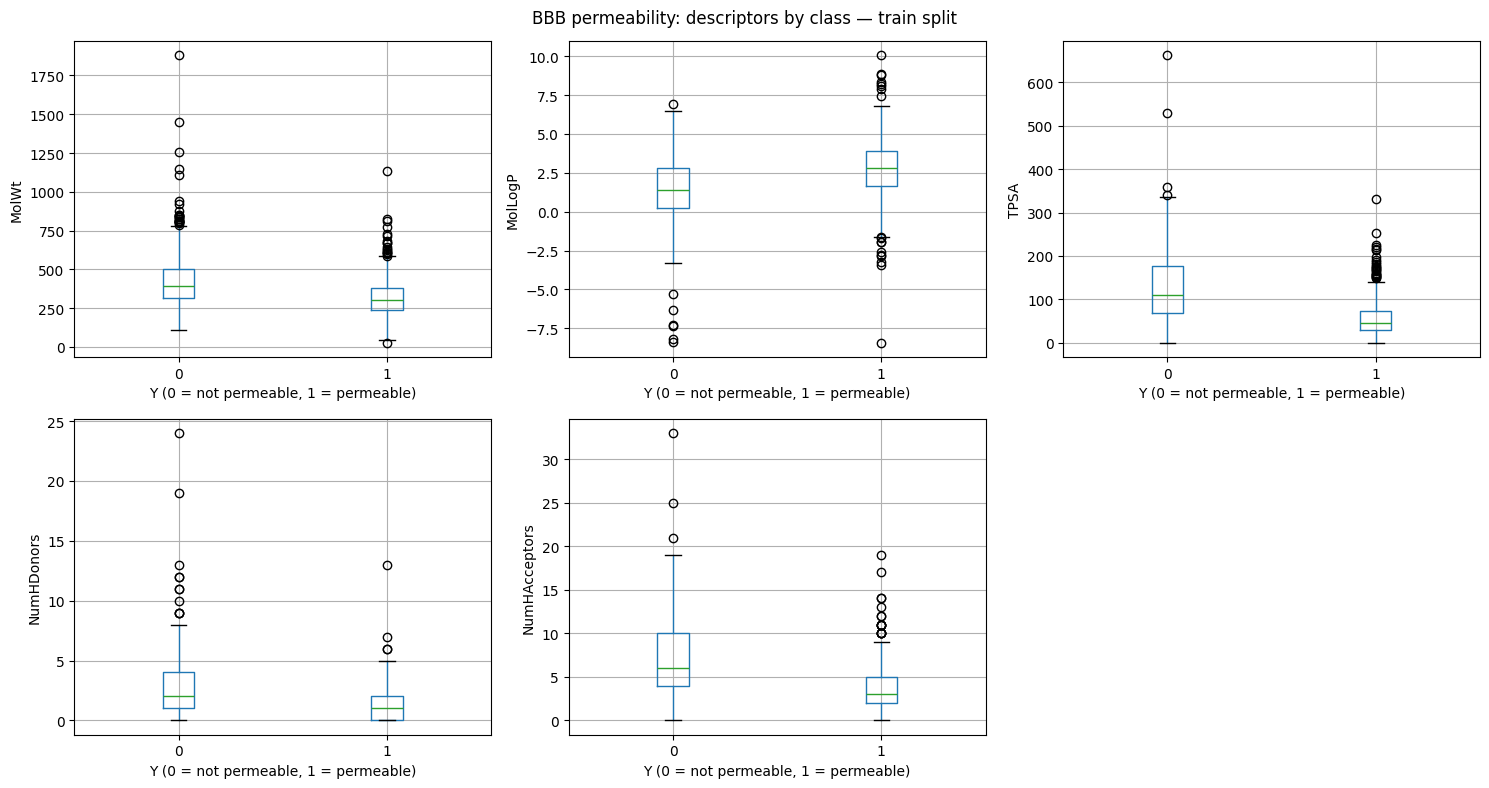

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, descriptor_cols):
    desc.boxplot(column=col, by='Y', ax=ax)
    ax.set_xlabel('Y (0 = not permeable, 1 = permeable)')
    ax.set_ylabel(col)
    ax.set_title('')

axes[-1].axis('off')  # unused 6th subplot
fig.suptitle('BBB permeability: descriptors by class — train split')
plt.tight_layout()
plt.show()

## 3. hERG Blockade (hERG) — EDA

Predicts whether a compound blocks the hERG cardiac ion channel — a binary classification task (`Y` = 1 blocker, 0 not). hERG blockade is a major cause of cardiotoxicity-driven drug failure. See `NOTES.md` for why this property matters in drug development.

In [19]:
hERG_split['train'].head()

,Drug_ID,Drug,Y
0,DEMETHYLASTEMIZOLE,Oc1ccc(CCN2CCC(Nc3nc4ccccc4n3Cc3ccc(F)cc3)CC2)cc1,1.0
1,GBR-12909,Fc1ccc(C(OCC[NH+]2CC[NH+](CCCc3ccccc3)CC2)c2cc...,1.0
2,CLOFILIUM PHOSPHATE,CCCCCCC[N+](CC)(CC)CCCCc1ccc(Cl)cc1.CCCCCCC[N+...,1.0
3,FLUSPIRILENE,O=C1NCN(c2ccccc2)C12CC[NH+](CCCC(c1ccc(F)cc1)c...,1.0
4,VANOXERINE HYDROCHLORIDE,Fc1ccc(C(OCCN2CCN(CCCc3ccccc3)CC2)c2ccc(F)cc2)cc1,1.0


In [20]:
# How many compounds?
for name, df in hERG_split.items():
    print(f"{name}: {df.shape[0]} compounds, {df.shape[1]} columns")

total = sum(df.shape[0] for df in hERG_split.values())
print(f"\ntotal: {total} compounds")

train: 458 compounds, 3 columns
valid: 66 compounds, 3 columns
test: 131 compounds, 3 columns

total: 655 compounds


In [21]:
# Any missing data?
for name, df in hERG_split.items():
    print(f"--- {name} ---")
    print(df.isna().sum())
    print()

--- train ---
Drug_ID    15
Drug        0
Y           0
dtype: int64

--- valid ---
Drug_ID    1
Drug       0
Y          0
dtype: int64

--- test ---
Drug_ID    6
Drug       0
Y          0
dtype: int64



Y
1.0    310
0.0    148
Name: count, dtype: int64

Y
1.0    0.676856
0.0    0.323144
Name: proportion, dtype: float64


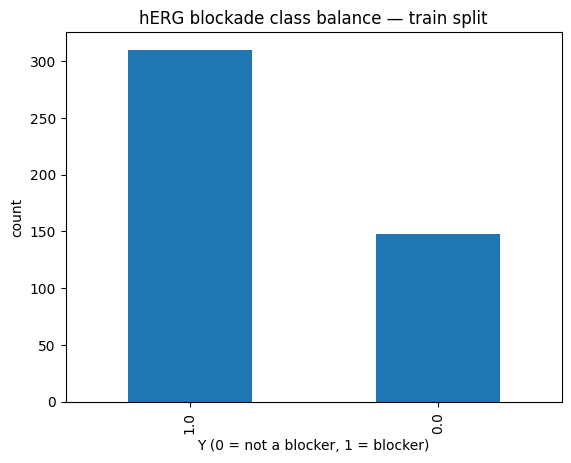

In [22]:
# Class balance
train = hERG_split['train']
print(train['Y'].value_counts())
print()
print(train['Y'].value_counts(normalize=True))

train['Y'].value_counts().plot(kind='bar')
plt.xlabel('Y (0 = not a blocker, 1 = blocker)')
plt.ylabel('count')
plt.title('hERG blockade class balance — train split')
plt.show()

In [23]:
# Sanity check: any duplicate compounds?
print("duplicate Drug_ID:", train['Drug_ID'].duplicated().sum())
print("duplicate SMILES (Drug):", train['Drug'].duplicated().sum())

duplicate Drug_ID: 22
duplicate SMILES (Drug): 5


In [24]:
# Do duplicate SMILES have conflicting labels?
dup_smiles = train[train['Drug'].duplicated(keep=False)]
n_groups = dup_smiles['Drug'].nunique()
conflicting = sum(g['Y'].nunique() > 1 for _, g in dup_smiles.groupby('Drug'))
print(f"{n_groups} duplicated SMILES groups in train; {conflicting} have conflicting labels")

5 duplicated SMILES groups in train; 2 have conflicting labels


In [25]:
# Does any molecule leak across splits?
train_smiles = set(hERG_split['train']['Drug'])
valid_smiles = set(hERG_split['valid']['Drug'])
test_smiles = set(hERG_split['test']['Drug'])

print("train/valid overlap:", len(train_smiles & valid_smiles))
print("train/test overlap:", len(train_smiles & test_smiles))
print("valid/test overlap:", len(valid_smiles & test_smiles))

train/valid overlap: 0
train/test overlap: 2
valid/test overlap: 0


In [26]:
# Investigate the 2 SMILES groups with conflicting labels
for smi, g in dup_smiles.groupby('Drug'):
    if g['Y'].nunique() > 1:
        print(g[['Drug_ID', 'Drug', 'Y']].to_string(index=False))
        print()

        Drug_ID                                   Drug   Y
BMCL20031829_19 CCC(=O)c1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12 1.0
   SERTINDOLE19 CCC(=O)c1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12 0.0

        Drug_ID                              Drug   Y
BMCL20031829_22 CCc1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12 1.0
   SERTINDOLE22 CCc1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12 0.0



**Decisions:**
- **Missing Drug_ID (22 rows across splits):** no action — `Drug` (SMILES) and `Y` are always present, and modeling uses SMILES/features, not the display name.
- **Conflicting labels (2 groups, both sertindole-related structural analogs — `BMCL20031829_19`/`SERTINDOLE19` and `BMCL20031829_22`/`SERTINDOLE22`):** same molecule, different source records disagree on blocker status. Same pattern as BBB's Trimetrexate/Levodopa conflict — genuine label noise, deferred to modeling time.
- **Train/test leakage (2 molecules):** noted, deferred to modeling time — small and consistent with the leakage pattern already seen in BBB.

### Descriptor plots

Same 5 descriptors and reasoning as before (see `NOTES.md` for definitions and the scatter-vs-box-plot rationale). Binary target → box plots grouped by class.

In [27]:
train = hERG_split['train']
desc = compute_descriptors(train['Drug'])
desc['Y'] = train['Y'].values
desc.groupby('Y')[descriptor_cols].describe().T

[10:45:40] WARNING: not removing hydrogen atom without neighbors
[10:45:40] WARNING: not removing hydrogen atom without neighbors


Y                           0.0         1.0
MolWt         count  148.000000  310.000000
              mean   328.310270  394.199597
              std    137.012416  102.355141
              min     94.117000  177.458000
              25%    233.817000  319.271250
              50%    302.260000  383.966500
              75%    404.390000  450.333250
              max    829.014000  838.066000
MolLogP       count  148.000000  310.000000
              mean     1.405197    3.182693
              std      2.001089    1.752310
              min     -3.011500   -4.606800
              25%     -0.230365    2.236280
              50%      1.396200    3.356150
              75%      2.703410    4.181725
              max      5.950920   10.291800
TPSA          count  148.000000  310.000000
              mean    83.871081   57.738581
              std     42.368777   38.188897
              min      4.930000    0.000000
              25%     57.950000   32.070000
              50%     77.975000   50.375000
              75%    103.950000   78.010000
              max    207.280000  218.090000
NumHDonors    count  148.000000  310.000000
              mean     2.013514    1.519355
              std      1.466109    1.242953
              min      0.000000    0.000000
              25%      1.000000    1.000000
              50%      2.000000    1.000000
              75%      3.000000    2.000000
              max      7.000000    8.000000
NumHAcceptors count  148.000000  310.000000
              mean     4.689189    3.700000
              std      2.707639    2.544809
              min      0.000000    0.000000
              25%      3.000000    2.000000
              50%      4.000000    3.000000
              75%      6.000000    5.000000
              max     15.000000   16.000000

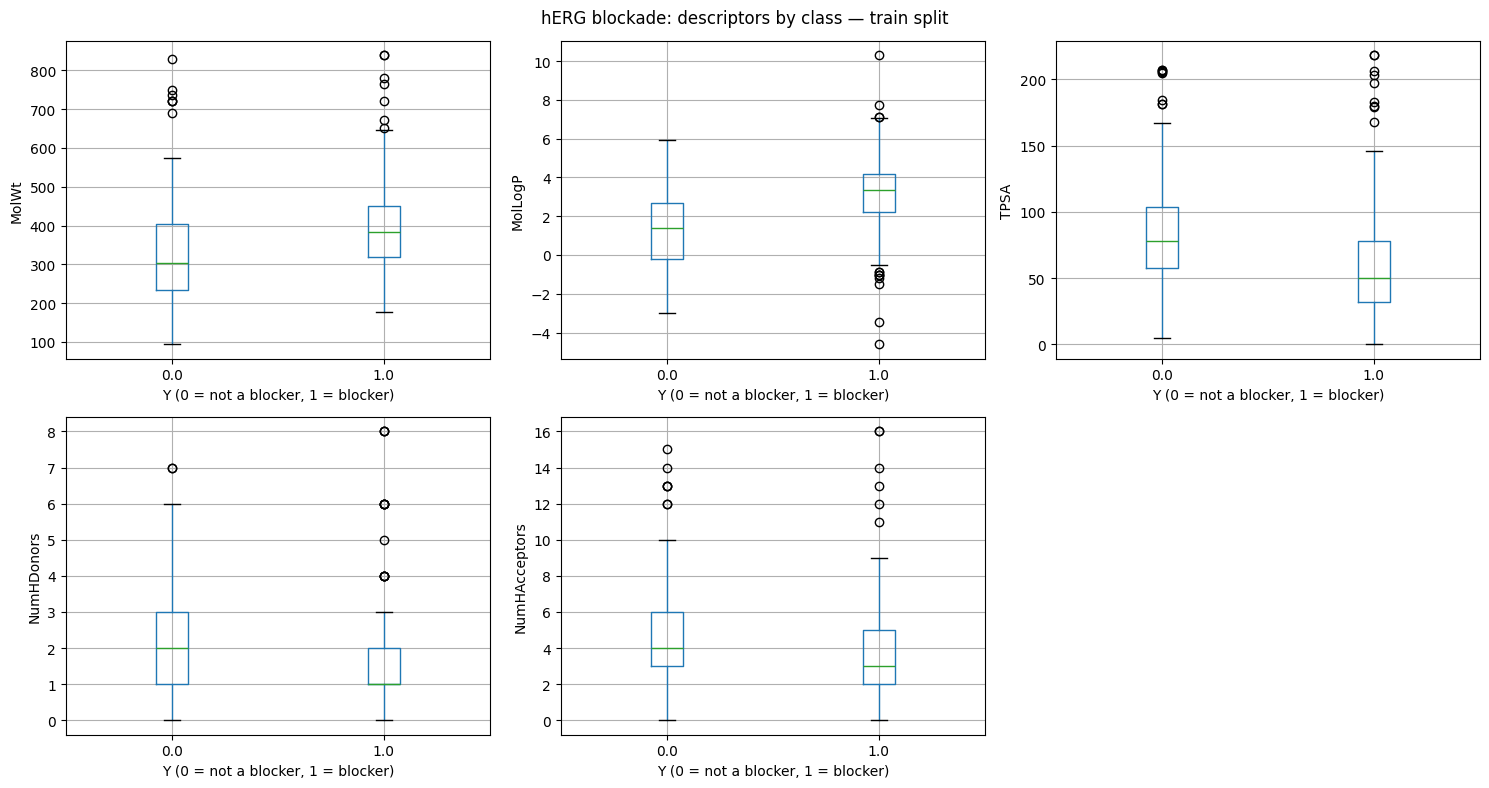

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, descriptor_cols):
    desc.boxplot(column=col, by='Y', ax=ax)
    ax.set_xlabel('Y (0 = not a blocker, 1 = blocker)')
    ax.set_ylabel(col)
    ax.set_title('')

axes[-1].axis('off')  # unused 6th subplot
fig.suptitle('hERG blockade: descriptors by class — train split')
plt.tight_layout()
plt.show()

## 4. CYP3A4 Inhibition (CYP3A4_Veith) — EDA

Predicts whether a compound inhibits the CYP3A4 metabolic enzyme — a binary classification task (`Y` = 1 inhibitor, 0 not). CYP3A4 metabolizes ~50% of marketed drugs, so inhibition is a major drug-drug interaction risk. Note: `Drug_ID` here is a numeric PubChem CID, not a compound name like the previous datasets. See `NOTES.md` for why this property matters in drug development.

In [29]:
CYP3A4_split['train'].head()

,Drug_ID,Drug,Y
0,644510.0,O=c1[nH]c2cc3c(cc2cc1CN(CCCO)Cc1nnnn1Cc1ccc(F)...,1
1,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,1
2,645063.0,CC(=O)Nc1cccc(NC(=O)C2CCCN2C(=O)Nc2ccccc2C)c1,0
3,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,1
4,6602688.0,Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c...,0


In [30]:
# How many compounds?
for name, df in CYP3A4_split.items():
    print(f"{name}: {df.shape[0]} compounds, {df.shape[1]} columns")

total = sum(df.shape[0] for df in CYP3A4_split.values())
print(f"\ntotal: {total} compounds")

train: 8629 compounds, 3 columns
valid: 1233 compounds, 3 columns
test: 2466 compounds, 3 columns

total: 12328 compounds


In [31]:
# Any missing data?
for name, df in CYP3A4_split.items():
    print(f"--- {name} ---")
    print(df.isna().sum())
    print()

--- train ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- valid ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- test ---
Drug_ID    0
Drug       0
Y          0
dtype: int64



Y
0    5052
1    3577
Name: count, dtype: int64

Y
0    0.585468
1    0.414532
Name: proportion, dtype: float64


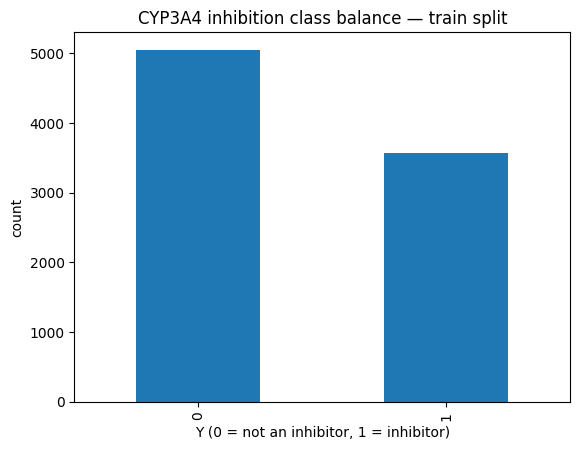

In [32]:
# Class balance
train = CYP3A4_split['train']
print(train['Y'].value_counts())
print()
print(train['Y'].value_counts(normalize=True))

train['Y'].value_counts().plot(kind='bar')
plt.xlabel('Y (0 = not an inhibitor, 1 = inhibitor)')
plt.ylabel('count')
plt.title('CYP3A4 inhibition class balance — train split')
plt.show()

In [33]:
# Sanity check: duplicates and cross-split leakage
print("duplicate Drug_ID:", train['Drug_ID'].duplicated().sum())
print("duplicate SMILES (Drug):", train['Drug'].duplicated().sum())

train_smiles = set(CYP3A4_split['train']['Drug'])
valid_smiles = set(CYP3A4_split['valid']['Drug'])
test_smiles = set(CYP3A4_split['test']['Drug'])
print("train/valid overlap:", len(train_smiles & valid_smiles))
print("train/test overlap:", len(train_smiles & test_smiles))
print("valid/test overlap:", len(valid_smiles & test_smiles))

duplicate Drug_ID: 0
duplicate SMILES (Drug): 0
train/valid overlap: 0
train/test overlap: 0
valid/test overlap: 0


### Descriptor plots

Same 5 descriptors and reasoning as before (see `NOTES.md`). Binary target → box plots grouped by class.

In [34]:
train = CYP3A4_split['train']
desc = compute_descriptors(train['Drug'])
desc['Y'] = train['Y'].values
desc.groupby('Y')[descriptor_cols].describe().T

Y                              0            1
MolWt         count  5052.000000  3577.000000
              mean    323.079344   390.208975
              std     109.309436    88.703839
              min      33.030000   134.142000
              25%     255.276000   332.444000
              50%     314.344500   381.501000
              75%     375.404750   436.499000
              max    1449.271000  1202.635000
MolLogP       count  5052.000000  3577.000000
              mean      2.318113     3.741537
              std       1.923189     1.250199
              min      -8.882800    -0.867200
              25%       1.166575     2.920120
              50%       2.357450     3.683100
              75%       3.521925     4.548200
              max      20.751200    10.291800
TPSA          count  5052.000000  3577.000000
              mean     75.206138    71.265046
              std      41.927176    26.428883
              min       0.000000     6.480000
              25%      50.190000    51.970000
              50%      69.720000    69.720000
              75%      91.502500    86.770000
              max     615.130000   278.800000
NumHDonors    count  5052.000000  3577.000000
              mean      1.419834     1.022086
              std       1.416349     0.845315
              min       0.000000     0.000000
              25%       1.000000     0.000000
              50%       1.000000     1.000000
              75%       2.000000     1.000000
              max      19.000000     8.000000
NumHAcceptors count  5052.000000  3577.000000
              mean      4.682304     5.144255
              std       2.428347     1.915406
              min       0.000000     1.000000
              25%       3.000000     4.000000
              50%       4.000000     5.000000
              75%       6.000000     6.000000
              max      29.000000    16.000000

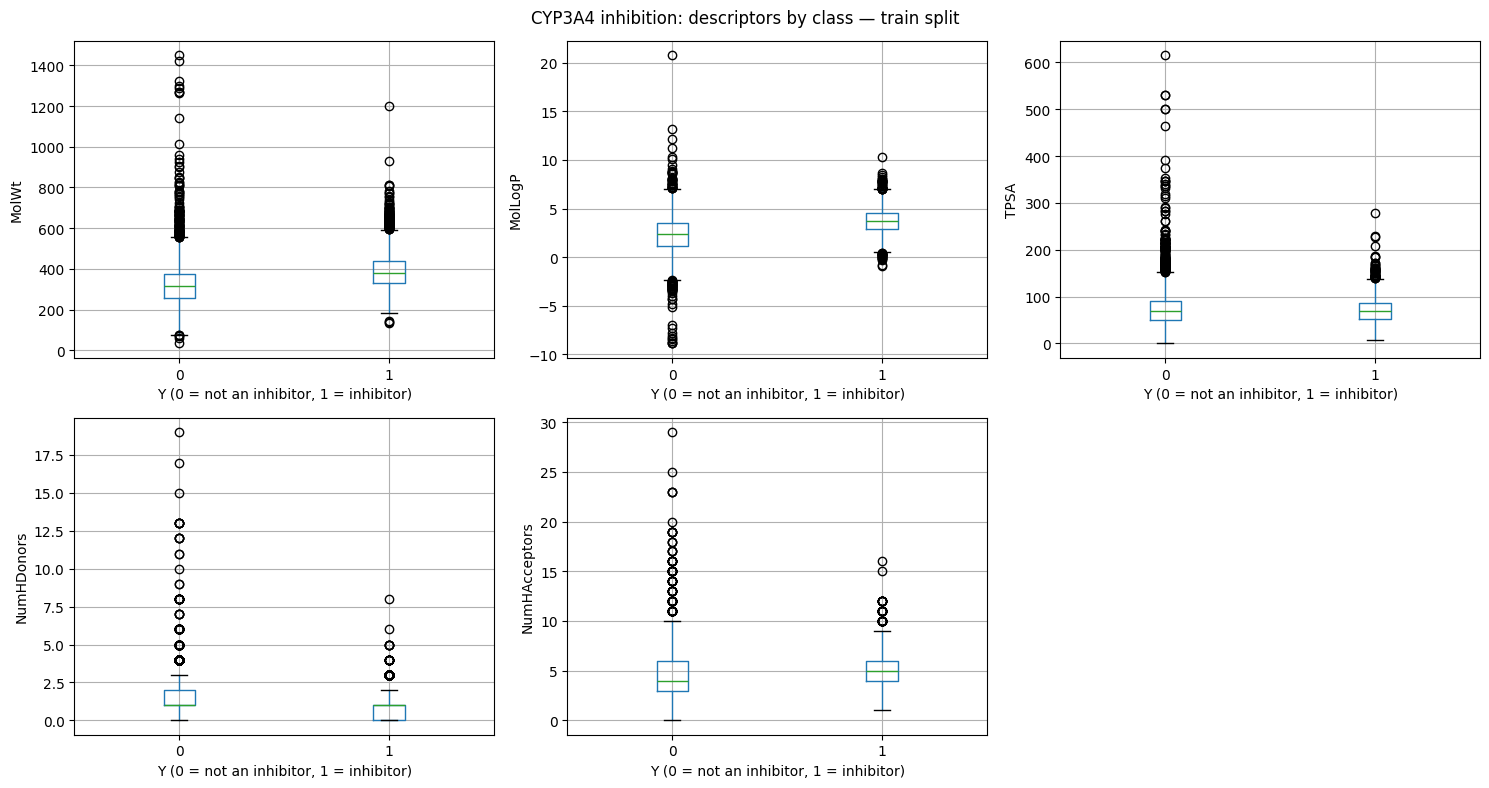

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, descriptor_cols):
    desc.boxplot(column=col, by='Y', ax=ax)
    ax.set_xlabel('Y (0 = not an inhibitor, 1 = inhibitor)')
    ax.set_ylabel(col)
    ax.set_title('')

axes[-1].axis('off')  # unused 6th subplot
fig.suptitle('CYP3A4 inhibition: descriptors by class — train split')
plt.tight_layout()
plt.show()

## 5. Clearance (Hepatocyte, AZ) — EDA

Predicts hepatocyte clearance — how fast the liver metabolizes/eliminates a compound (µL/min/million cells) — a regression task. The last of the 5 datasets in this panel. See `NOTES.md` for why this property matters in drug development.

In [36]:
clearance_split['train'].head()

,Drug_ID,Drug,Y
0,CHEMBL2177601,Cc1c(C(=O)NC2C3CC4CC(C3)CC2C4)cnn1-c1ccc(C(=O)...,3.00
1,CHEMBL1956129,C[C@@](CCc1ccc(-c2ccc(Cl)cc2)cc1)(C(=O)NO)S(C)...,3.00
2,CHEMBL1940832,O=CNc1cc([C@@H](O)CNCCc2ccc(NC[C@H](O)c3ccccc3...,3.00
3,CHEMBL29609,Cc1cc(CCCOc2c(C)cc(-c3noc(C(F)(F)F)n3)cc2C)on1,13.49
4,CHEMBL1829783,C[C@@H](c1ccc(-c2ccc(F)cc2F)cc1)N1CC[C@@](CCO)...,64.57


In [37]:
# How many compounds?
for name, df in clearance_split.items():
    print(f"{name}: {df.shape[0]} compounds, {df.shape[1]} columns")

total = sum(df.shape[0] for df in clearance_split.values())
print(f"\ntotal: {total} compounds")

train: 849 compounds, 3 columns
valid: 121 compounds, 3 columns
test: 243 compounds, 3 columns

total: 1213 compounds


In [38]:
# Any missing data?
for name, df in clearance_split.items():
    print(f"--- {name} ---")
    print(df.isna().sum())
    print()

--- train ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- valid ---
Drug_ID    0
Drug       0
Y          0
dtype: int64

--- test ---
Drug_ID    0
Drug       0
Y          0
dtype: int64



**Class balance:** not applicable — regression task (`Y` is a continuous clearance value). Looking at the distribution of `Y` instead.

count    849.000000
mean      42.772085
std       49.762234
min        3.000000
25%        6.000000
50%       19.050000
75%       61.660000
max      150.000000
Name: Y, dtype: float64


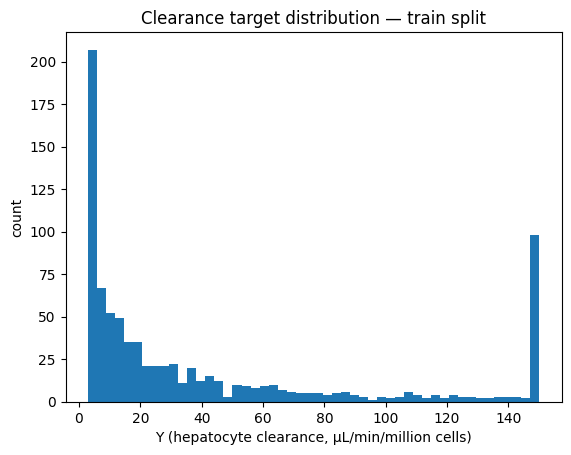

In [39]:
train = clearance_split['train']
print(train['Y'].describe())

plt.hist(train['Y'], bins=50)
plt.xlabel('Y (hepatocyte clearance, µL/min/million cells)')
plt.ylabel('count')
plt.title('Clearance target distribution — train split')
plt.show()

In [40]:
# Sanity check: duplicates and cross-split leakage
print("duplicate Drug_ID:", train['Drug_ID'].duplicated().sum())
print("duplicate SMILES (Drug):", train['Drug'].duplicated().sum())

train_smiles = set(clearance_split['train']['Drug'])
valid_smiles = set(clearance_split['valid']['Drug'])
test_smiles = set(clearance_split['test']['Drug'])
print("train/valid overlap:", len(train_smiles & valid_smiles))
print("train/test overlap:", len(train_smiles & test_smiles))
print("valid/test overlap:", len(valid_smiles & test_smiles))

duplicate Drug_ID: 94
duplicate SMILES (Drug): 94
train/valid overlap: 30
train/test overlap: 54
valid/test overlap: 5


Regression's version of "conflicting labels": for duplicate SMILES, how much does `Y` vary between replicate measurements of the same molecule?

In [41]:
dup_smiles = train[train['Drug'].duplicated(keep=False)]
spread = dup_smiles.groupby('Drug')['Y'].agg(['min', 'max', 'count'])
spread['range'] = spread['max'] - spread['min']

print(f"{len(spread)} duplicated SMILES groups in train")
print(f"mean range between replicate measurements: {spread['range'].mean():.1f}")
print(f"median range: {spread['range'].median():.1f}")
print()
print("largest-spread duplicate groups:")
print(spread.sort_values('range', ascending=False).head(10))

94 duplicated SMILES groups in train
mean range between replicate measurements: 36.4
median range: 18.9

largest-spread duplicate groups:
                                                      min    max  count  \
Drug                                                                      
CN1CCN(C2=Nc3cc(Cl)ccc3Nc3ccccc32)CC1                6.76  150.0      2   
CC(C)NCC(O)COc1cccc2[nH]ccc12                        7.59  150.0      2   
CN(C)CCCOc1nn(Cc2ccccc2)c2ccccc12                    7.76  150.0      2   
C[C@H]1C[C@H]2[C@@H]3CC[C@](O)(C(=O)CO)[C@@]3(C...   9.12  150.0      2   
COc1ccc([C@@H]2Sc3ccccc3N(CCN(C)C)C(=O)[C@@H]2O...   9.33  150.0      2   
O=C(Nc1cc(-c2ccnc(Nc3ccc(F)cc3)c2)ccn1)C1CCOCC1     14.79  150.0      2   
O=C(Nc1cc(-c2ccnc(Nc3ccccc3)c2)ccn1)C1CCOCC1        16.22  150.0      2   
CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)C...  16.60  150.0      2   
COC(=O)C1=C(C)NC(C)=C(C(=O)OC)C1c1ccccc1[N+](=O...  22.39  150.0      2   
Cc1c(C)c2c(c(C)c1O)CCC(C)(COc1ccc(CC3

The largest-spread duplicate groups all top out at exactly the dataset max (`Y=150.0`) — that's suspicious. Checking whether `Y` is pinned at round floor/ceiling values across the whole dataset, which would suggest assay censoring (e.g. "&gt;150" or "&lt;3" reported as the boundary value rather than a real measurement).

In [42]:
print("Y min:", train['Y'].min(), "| Y max:", train['Y'].max())
print(f"rows at min ({train['Y'].min()}):", (train['Y'] == train['Y'].min()).sum(), f"/ {len(train)}")
print(f"rows at max ({train['Y'].max()}):", (train['Y'] == train['Y'].max()).sum(), f"/ {len(train)}")

n_capped_dup_groups = (spread['max'] == train['Y'].max()).sum()
print(f"\nduplicate groups where one replicate hits the max: {n_capped_dup_groups} / {len(spread)}")

Y min: 3.0 | Y max: 150.0
rows at min (3.0): 133 / 849
rows at max (150.0): 96 / 849

duplicate groups where one replicate hits the max: 15 / 94


**Decisions:**
- **Assay censoring (16% of rows at `Y=3.0`, 11% at `Y=150.0`):** flagged as a modeling constraint, not a data-cleaning issue to fix now. `Y` likely represents `<3` and `>150` assay boundaries rather than true point measurements near the extremes. At modeling time, consider a censored-regression approach or bucketing into low/medium/high categories instead of treating `Y` as an ordinary continuous target throughout its full range.
- **Duplicate SMILES (94/849, 11%) and train/valid/test leakage (30/54/5 overlaps):** by far the worst data quality of the 5 datasets in this panel. Noted, deferred to modeling time — consistent with how BBB/hERG leakage was handled, but this dataset will need the most deliberate cleanup before it can be trusted for evaluation.

### Descriptor plots

Same 5 descriptors and reasoning as before (see `NOTES.md`). Regression target → scatter plots.

In [43]:
train = clearance_split['train']
desc = compute_descriptors(train['Drug'])
desc['Y'] = train['Y'].values
desc.describe()

,MolWt,MolLogP,TPSA,NumHDonors,NumHAcceptors,Y
count,849.000000,849.000000,849.000000,849.000000,849.000000,849.000000
mean,404.669522,3.479314,81.952792,1.772674,5.208481,42.772085
std,115.608444,1.537246,38.408413,1.506717,2.249764,49.762234
min,147.177000,-4.851700,3.240000,0.000000,1.000000,3.000000
25%,332.337000,2.598000,57.530000,1.000000,4.000000,6.000000
50%,409.486000,3.486420,80.670000,2.000000,5.000000,19.050000
75%,474.587000,4.374260,99.770000,2.000000,7.000000,61.660000
max,1160.430000,8.976620,470.430000,17.000000,17.000000,150.000000


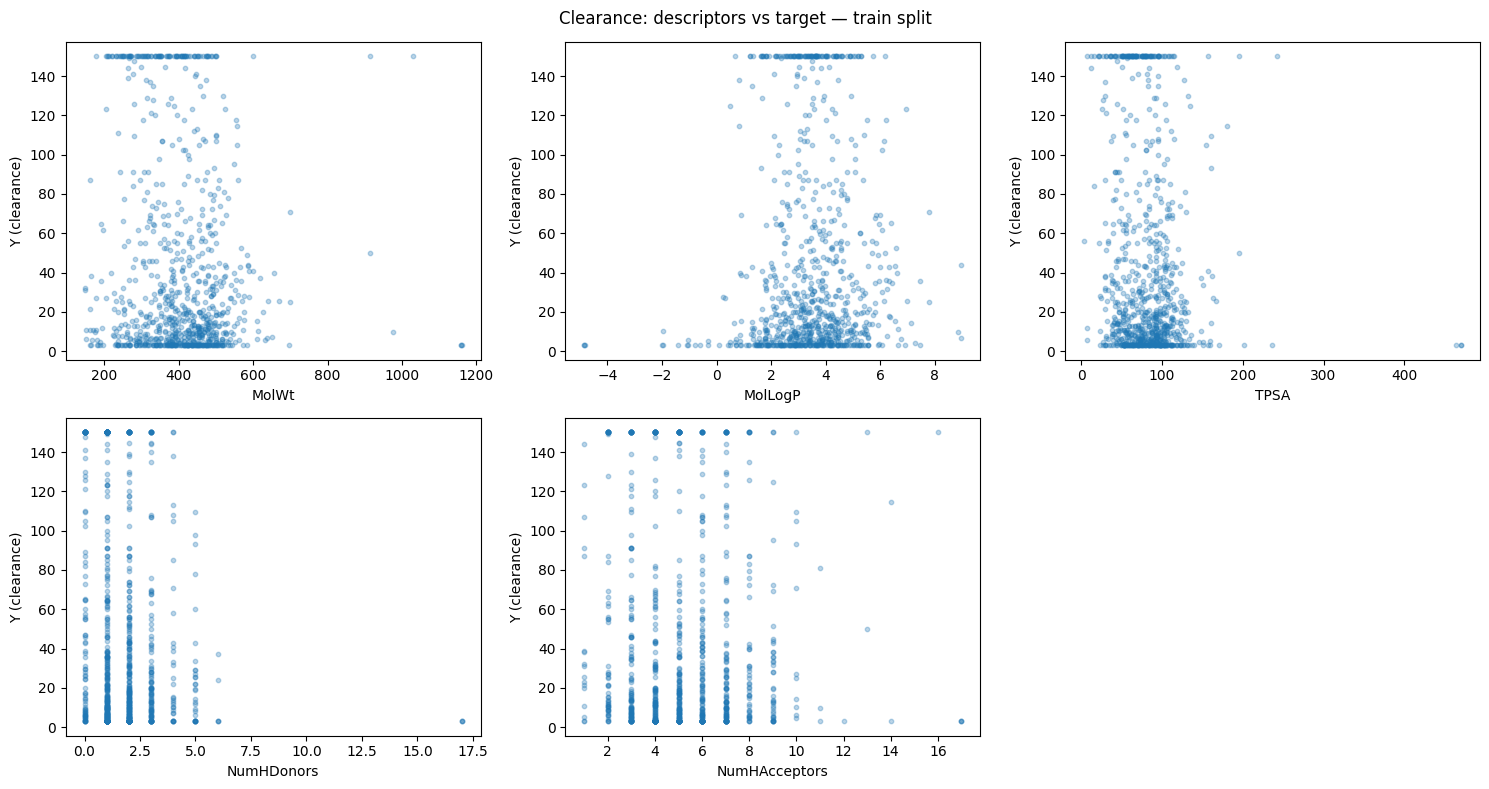

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, descriptor_cols):
    ax.scatter(desc[col], desc['Y'], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Y (clearance)')

axes[-1].axis('off')  # unused 6th subplot
fig.suptitle('Clearance: descriptors vs target — train split')
plt.tight_layout()
plt.show()